In [1]:
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (299, 299)
IMG_HEIGHT = 299
IMG_WIDTH = 299

BATCH_SIZE = 8

NUM_CLASSES = 4

CLASS_NAMES = [
    "Melanoma",
    "Basal Cell Carcinoma",
    "Squamous Cell Carcinoma",
    "MCC"
]
WORK_DIR = "/kaggle/working/classification_improved_v2"

os.makedirs(WORK_DIR, exist_ok=True)

MODEL_DIR = os.path.join(WORK_DIR, "models")
AUG_DIR = os.path.join(WORK_DIR, "augmented")
DATA_DIR = os.path.join(WORK_DIR, "data")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(AUG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("=" * 60)
print("CLASSIFICATION IMPROVED V2")
print("=" * 60)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("GPU count:", len(gpus))

if gpus:
    print("GPU available:")
    for gpu in gpus:
        print(" ", gpu)
else:
    print("WARNING: GPU not detected.")

gc.collect()

print("\nConfiguration")
print("-" * 60)
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Classes    :", NUM_CLASSES)
print("Class names:", CLASS_NAMES)
print("Work dir   :", WORK_DIR)

CLASSIFICATION IMPROVED V2
TensorFlow version: 2.20.0
GPU count: 0

Configuration
------------------------------------------------------------
Image size : (299, 299)
Batch size : 8
Classes    : 4
Class names: ['Melanoma', 'Basal Cell Carcinoma', 'Squamous Cell Carcinoma', 'MCC']
Work dir   : /kaggle/working/classification_improved_v2


2026-09-06 15:27:59.485256: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
DERMACON_PATH = (
    "/kaggle/input/datasets/hiro002/dermacon-in-dataset"
)

# MCC datasets
MCC_DATASET_1 = (
    "/kaggle/input/datasets/quantumcoders05/mcc-3-dataset3"
)

MCC_DATASET_2 = (
    "/kaggle/input/datasets/quantumcoders05/mcc-dataset"
)

MCC_DATASET_3 = (
    "/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma-04"
)

MCC_DATASET_4 = (
    "/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma01"
)

# SCC dataset
SCC_DATASET = (
    "/kaggle/input/datasets/quantumcoders05/scc-dataset"
)

# ISIC 9-class dataset
ISIC_9CLASS = (
    "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic"
)

# HAM10000
HAM10000_PATH = (
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
)

# All ISIC data
ALL_ISIC_PATH = (
    "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"
)

DATASET_PATHS = {
    "DermaCon-IN": DERMACON_PATH,
    "MCC-3": MCC_DATASET_1,
    "MCC": MCC_DATASET_2,
    "MCC-04": MCC_DATASET_3,
    "MCC-01": MCC_DATASET_4,
    "SCC": SCC_DATASET,
    "ISIC-9": ISIC_9CLASS,
    "HAM10000": HAM10000_PATH,
    "All-ISIC": ALL_ISIC_PATH
}

print("=" * 70)
print("DATASET PATH CHECK")
print("=" * 70)

for name, path in DATASET_PATHS.items():

    exists = os.path.exists(path)

    print(
        f"{name:<15} : "
        f"{'✓ FOUND' if exists else '✗ NOT FOUND'}"
    )

    if not exists:
        print("   ", path)

DATASET PATH CHECK
DermaCon-IN     : ✓ FOUND
MCC-3           : ✓ FOUND
MCC             : ✓ FOUND
MCC-04          : ✓ FOUND
MCC-01          : ✓ FOUND
SCC             : ✓ FOUND
ISIC-9          : ✓ FOUND
HAM10000        : ✓ FOUND
All-ISIC        : ✓ FOUND


In [3]:
def inspect_dataset(name, path):

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    if not os.path.exists(path):
        print("NOT FOUND")
        return

    # Top-level items
    try:
        items = os.listdir(path)

        print("\nTop-level items:")

        for item in items[:30]:
            full_path = os.path.join(path, item)

            if os.path.isdir(full_path):
                print(f"  [DIR]  {item}")
            else:
                print(f"  [FILE] {item}")

    except Exception as e:
        print("Error:", e)


# Inspect all datasets

for name, path in DATASET_PATHS.items():
    inspect_dataset(name, path)


DermaCon-IN

Top-level items:
  [DIR]  METADATA
  [FILE] train_CBM_SC_MC_type2.py
  [FILE] Infer_Swin_MC.ipynb
  [DIR]  DATASET
  [DIR]  checkpoints
  [FILE] Infer_CBM_MC.ipynb
  [FILE] README.md
  [FILE] train_CBM_SC_MC_type1.py
  [FILE] train_cbm_mc.py
  [FILE] Metadata_schema.md
  [FILE] train_swin_mc.py

MCC-3

Top-level items:
  [DIR]  MCC-3

MCC

Top-level items:
  [DIR]  Merkel Cell Carcinoma in Skin of Color Patients A Case Series

MCC-04

Top-level items:
  [DIR]  New folder

MCC-01

Top-level items:
  [DIR]  MCC-2

SCC

Top-level items:
  [DIR]  SCC-1

ISIC-9

Top-level items:
  [DIR]  Skin cancer ISIC The International Skin Imaging Collaboration
  [DIR]  skin cancer isic the international skin imaging collaboration

HAM10000

Top-level items:
  [FILE] hmnist_8_8_RGB.csv
  [FILE] hmnist_28_28_RGB.csv
  [DIR]  HAM10000_images_part_1
  [DIR]  ham10000_images_part_1
  [FILE] hmnist_8_8_L.csv
  [DIR]  HAM10000_images_part_2
  [DIR]  ham10000_images_part_2
  [FILE] hmnist_28_28_L

In [4]:
print("=" * 80)
print("SEARCHING FOR METADATA / LABEL FILES")
print("=" * 80)

extensions = (
    ".csv",
    ".json",
    ".xlsx",
    ".xls",
    ".txt"
)

for name, path in DATASET_PATHS.items():

    print("\n" + "-" * 80)
    print(name)
    print("-" * 80)

    found = []

    for root, dirs, files in os.walk(path):

        for file in files:

            if file.lower().endswith(extensions):

                full_path = os.path.join(root, file)
                found.append(full_path)

    if found:

        for file_path in found[:30]:
            print(file_path)

        if len(found) > 30:
            print(
                f"... and {len(found) - 30} more files"
            )

    else:
        print("No metadata files found.")

SEARCHING FOR METADATA / LABEL FILES

--------------------------------------------------------------------------------
DermaCon-IN
--------------------------------------------------------------------------------
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/train_split.csv
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/test_split.csv
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/Skin_Metadata.csv

--------------------------------------------------------------------------------
MCC-3
--------------------------------------------------------------------------------
No metadata files found.

--------------------------------------------------------------------------------
MCC
--------------------------------------------------------------------------------
No metadata files found.

--------------------------------------------------------------------------------
MCC-04
--------------------------------------------------------------------------------
No 

In [5]:
HAM_METADATA = os.path.join(
    HAM10000_PATH,
    "HAM10000_metadata.csv"
)

ham_df = pd.read_csv(HAM_METADATA)

print("=" * 70)
print("HAM10000 METADATA")
print("=" * 70)

print("Shape:", ham_df.shape)

print("\nColumns:")
print(ham_df.columns.tolist())

print("\nDiagnosis distribution:")
print(ham_df["dx"].value_counts())

HAM_LABEL_MAP = {
    "mel": "Melanoma",
    "bcc": "Basal Cell Carcinoma"
}


# Select only our required classes

ham_selected = ham_df[
    ham_df["dx"].isin(HAM_LABEL_MAP.keys())
].copy()

ham_selected["class_name"] = ham_selected["dx"].map(
    HAM_LABEL_MAP
)

HAM_IMAGE_DIRS = [
    os.path.join(
        HAM10000_PATH,
        "HAM10000_images_part_1"
    ),
    os.path.join(
        HAM10000_PATH,
        "HAM10000_images_part_2"
    ),
    os.path.join(
        HAM10000_PATH,
        "ham10000_images_part_1"
    ),
    os.path.join(
        HAM10000_PATH,
        "ham10000_images_part_2"
    )
]


# Create image lookup

ham_image_lookup = {}

for image_dir in HAM_IMAGE_DIRS:

    if not os.path.exists(image_dir):
        continue

    for filename in os.listdir(image_dir):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            image_id = os.path.splitext(filename)[0]

            ham_image_lookup[image_id] = os.path.join(
                image_dir,
                filename
            )


# Add image paths

ham_selected["image_path"] = ham_selected[
    "image_id"
].map(ham_image_lookup)


# Keep valid images only

ham_selected = ham_selected[
    ham_selected["image_path"].notna()
].copy()


ham_selected["dataset"] = "HAM10000"

print("\n" + "=" * 70)
print("HAM10000 SELECTED DATA")
print("=" * 70)

print("Selected images:", len(ham_selected))

print("\nClass distribution:")

print(
    ham_selected["class_name"].value_counts()
)

print("\nMissing image paths:",
      ham_selected["image_path"].isna().sum())

display(
    ham_selected[
        [
            "image_id",
            "dx",
            "class_name",
            "dataset",
            "image_path"
        ]
    ].head()
)

HAM10000 METADATA
Shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Diagnosis distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

HAM10000 SELECTED DATA
Selected images: 1627

Class distribution:
class_name
Melanoma                1113
Basal Cell Carcinoma     514
Name: count, dtype: int64

Missing image paths: 0


,image_id,dx,class_name,dataset,image_path
1211,ISIC_0025964,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1212,ISIC_0030623,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1213,ISIC_0027190,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1214,ISIC_0031023,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1215,ISIC_0028086,mel,Melanoma,HAM10000,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [6]:
print("=" * 70)
print("ISIC-9 - SCC EXTRACTION")
print("=" * 70)

scc_paths = []

for root, dirs, files in os.walk(ISIC_9CLASS):

    # We only want SCC folders
    folder_name = os.path.basename(root).lower()

    if folder_name == "squamous cell carcinoma":

        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                scc_paths.append(
                    os.path.join(root, file)
                )


# Remove duplicate paths
scc_paths = sorted(list(set(scc_paths)))


# Create dataframe

scc_isic_df = pd.DataFrame({
    "image_path": scc_paths
})

scc_isic_df["class_name"] = (
    "Squamous Cell Carcinoma"
)

scc_isic_df["dataset"] = "ISIC-9"

print("\nSCC images found:", len(scc_isic_df))

print("\nClass distribution:")

print(
    scc_isic_df["class_name"].value_counts()
)

print("\nSample paths:")

display(
    scc_isic_df.head()
)

ISIC-9 - SCC EXTRACTION

SCC images found: 394

Class distribution:
class_name
Squamous Cell Carcinoma    394
Name: count, dtype: int64

Sample paths:


,image_path,class_name,dataset
0,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9
1,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9
2,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9
3,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9
4,/kaggle/input/datasets/nodoubttome/skin-cancer...,Squamous Cell Carcinoma,ISIC-9


In [7]:
print("=" * 70)
print("MCC DATASET EXTRACTION")
print("=" * 70)

MCC_PATHS = {
    "MCC-3": MCC_DATASET_1,
    "MCC-Case-Series": MCC_DATASET_2,
    "MCC-04": MCC_DATASET_3,
    "MCC-01": MCC_DATASET_4,
}

mcc_rows = []

for dataset_name, dataset_path in MCC_PATHS.items():

    print(f"\nScanning: {dataset_name}")
    print(dataset_path)

    count_before = len(mcc_rows)

    for root, dirs, files in os.walk(dataset_path):

        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            ):

                full_path = os.path.join(root, file)

                mcc_rows.append({
                    "image_path": full_path,
                    "class_name": "MCC",
                    "dataset": dataset_name
                })

    count_after = len(mcc_rows)

    print(
        "Images found:",
        count_after - count_before
    )


# Create dataframe

mcc_df = pd.DataFrame(mcc_rows)


# Remove duplicate image paths

before_duplicates = len(mcc_df)

mcc_df = mcc_df.drop_duplicates(
    subset=["image_path"]
).reset_index(drop=True)

after_duplicates = len(mcc_df)

print("\n" + "=" * 70)
print("MCC SUMMARY")
print("=" * 70)

print(
    "Total images before duplicate removal:",
    before_duplicates
)

print(
    "Duplicate images removed:",
    before_duplicates - after_duplicates
)

print(
    "Final unique MCC images:",
    after_duplicates
)

print("\nDataset-wise distribution:")

print(
    mcc_df["dataset"].value_counts()
)

print("\nClass distribution:")

print(
    mcc_df["class_name"].value_counts()
)

print("\nSample images:")

display(mcc_df.head())

MCC DATASET EXTRACTION

Scanning: MCC-3
/kaggle/input/datasets/quantumcoders05/mcc-3-dataset3
Images found: 20

Scanning: MCC-Case-Series
/kaggle/input/datasets/quantumcoders05/mcc-dataset
Images found: 6

Scanning: MCC-04
/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma-04
Images found: 12

Scanning: MCC-01
/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma01
Images found: 10

MCC SUMMARY
Total images before duplicate removal: 48
Duplicate images removed: 0
Final unique MCC images: 48

Dataset-wise distribution:
dataset
MCC-3              20
MCC-04             12
MCC-01             10
MCC-Case-Series     6
Name: count, dtype: int64

Class distribution:
class_name
MCC    48
Name: count, dtype: int64

Sample images:


,image_path,class_name,dataset
0,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3
1,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3
2,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3
3,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3
4,/kaggle/input/datasets/quantumcoders05/mcc-3-d...,MCC,MCC-3


In [8]:
print("=" * 70)
print("SCC ADDITIONAL DATASET")
print("=" * 70)

scc_extra_rows = []

for root, dirs, files in os.walk(SCC_DATASET):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            scc_extra_rows.append({
                "image_path": os.path.join(root, file),
                "class_name": "Squamous Cell Carcinoma",
                "dataset": "SCC-Additional"
            })


scc_extra_df = pd.DataFrame(scc_extra_rows)

# Remove duplicate paths within this dataset
scc_extra_df = scc_extra_df.drop_duplicates(
    subset=["image_path"]
).reset_index(drop=True)


print("\nAdditional SCC images:",
      len(scc_extra_df))

print("\nDistribution:")
print(
    scc_extra_df["class_name"].value_counts()
)

display(scc_extra_df.head())

SCC ADDITIONAL DATASET

Additional SCC images: 12

Distribution:
class_name
Squamous Cell Carcinoma    12
Name: count, dtype: int64


,image_path,class_name,dataset
0,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional
1,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional
2,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional
3,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional
4,/kaggle/input/datasets/quantumcoders05/scc-dat...,Squamous Cell Carcinoma,SCC-Additional


In [9]:
import os
import pandas as pd

DERMACON_PATH = "/kaggle/input/datasets/hiro002/dermacon-in-dataset"

print("=" * 70)
print("DERMACON-IN METADATA")
print("=" * 70)

TRAIN_META = os.path.join(
    DERMACON_PATH,
    "METADATA",
    "train_split.csv"
)

TEST_META = os.path.join(
    DERMACON_PATH,
    "METADATA",
    "test_split.csv"
)

SKIN_META = os.path.join(
    DERMACON_PATH,
    "METADATA",
    "Skin_Metadata.csv"
)

dermacon_train = pd.read_csv(TRAIN_META)
dermacon_test = pd.read_csv(TEST_META)
dermacon_skin = pd.read_csv(SKIN_META)


print("\nTrain split:")
print("Shape:", dermacon_train.shape)
print("Columns:")
print(dermacon_train.columns.tolist())


print("\nTest split:")
print("Shape:", dermacon_test.shape)
print("Columns:")
print(dermacon_test.columns.tolist())


print("\nSkin Metadata:")
print("Shape:", dermacon_skin.shape)
print("Columns:")
print(dermacon_skin.columns.tolist())

print("\n" + "=" * 70)
print("TRAIN SAMPLE")
print("=" * 70)

display(dermacon_train.head())


print("\n" + "=" * 70)
print("SKIN METADATA SAMPLE")
print("=" * 70)

display(dermacon_skin.head())

DERMACON-IN METADATA

Train split:
Shape: (4399, 108)
Columns:
['Age', 'Body_part_Armpits (Axillary Region)', 'Body_part_Back', 'Body_part_Back of the Knees (Popliteal Region)', 'Body_part_Breasts (Mammary Region)', 'Body_part_Calves (Sural Region)', 'Body_part_Genital Area (Pubic Region)', 'Body_part_Groin (Inguinal Region)', 'Body_part_Head Cheeks', 'Body_part_Head Chin', 'Body_part_Head Ears', 'Body_part_Head Eye', 'Body_part_Head Forehead', 'Body_part_Head Lips', 'Body_part_Head Nose', 'Body_part_Head Scalp', 'Body_part_Head Temples', 'Body_part_Lower Extremities Ankles (Tarsal Region)', 'Body_part_Lower Extremities Feet (Pedal Region)', 'Body_part_Lower Extremities Feet (Pedal Region) Toes (Digits)', 'Body_part_Lower Extremities Hips (Coxal Region)', 'Body_part_Lower Extremities Knees (Patellar Region)', 'Body_part_Lower Extremities Lower Legs', 'Body_part_Lower Extremities Lower Legs (Crural Region)', 'Body_part_Lower Extremities Soles (Plantar Region)', 'Body_part_Lower Extremit

,Age,Body_part_Armpits (Axillary Region),Body_part_Back,Body_part_Back of the Knees (Popliteal Region),Body_part_Breasts (Mammary Region),Body_part_Calves (Sural Region),Body_part_Genital Area (Pubic Region),Body_part_Groin (Inguinal Region),Body_part_Head Cheeks,Body_part_Head Chin,...,Disease_label,Fitzpatrick,Gradability,Image_name,Main_class,Monk_skin_tone,Quality,Sex,Sub_class,Subject_ID
0,10 - 20,0,0,0,0,0,0,1,0,0,...,Steroid Modified Tinea,FST 3,Yes,IMG_0002.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
1,10 - 20,0,0,0,0,0,0,1,0,0,...,Steroid Modified Tinea,FST 3,Yes,IMG_0005.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
2,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0009.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
3,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0010.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
4,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0011.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002



SKIN METADATA SAMPLE


,Age,Body_part,Descriptors,Confidence,Disease_label,Fitzpatrick,Gradability,Image_name,Main_class,Monk_skin_tone,Quality,Sex,Sub_class,Subject_ID
0,10 - 20,"Groin (Inguinal Region),Lower Extremities Thig...","Erythema, Pigmented, Plaque",5,Steroid Modified Tinea,FST 3,Yes,IMG_0002.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
1,10 - 20,"Groin (Inguinal Region),Lower Extremities Thig...","Erythema, Pigmented, Plaque",5,Steroid Modified Tinea,FST 3,Yes,IMG_0005.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
2,40 - 60,Head Cheeks,Papule,5,Acne,FST 4,Yes,IMG_0009.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
3,40 - 60,Head Cheeks,Papule,5,Acne,FST 4,Yes,IMG_0010.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002
4,40 - 60,"Head Cheeks,Head Nose,Head Lips",Papule,5,Acne,FST 4,Yes,IMG_0011.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002


In [10]:
print("=" * 70)
print("DERMACON-IN LABEL DISTRIBUTION")
print("=" * 70)

print("\nMAIN CLASS:")
print(
    dermacon_skin["Main_class"].value_counts()
)

print("\n" + "-" * 70)
print("SUB CLASS:")
print(
    dermacon_skin["Sub_class"].value_counts()
)

print("\n" + "-" * 70)
print("DISEASE LABEL:")
print(
    dermacon_skin["Disease_label"].value_counts()
)

DERMACON-IN LABEL DISTRIBUTION

MAIN CLASS:
Main_class
Infectious Disorders         2227
Inflammatory Disorders       1592
Pigmentary Disorders          831
Skin Appendages Disorders     480
Other skin disorders          159
Keratanisation Disorders       72
Neoplasms and tumors           52
No Definite Diagnosis          37
Name: count, dtype: int64

----------------------------------------------------------------------
SUB CLASS:
Sub_class
Infectious skin conditions -Fungal                                                1513
Pigmentary Disorders                                                               831
Inflammatory skin diseases (Eczema and Dermatitis)                                 727
Inflammatory skin diseases (Other)                                                 447
Inflammatory skin diseases (Psoriasis and Lichenoid disorders)                     418
Sebacious Glands and Acneiform Disorders                                           352
Infectious skin conditions -Para

In [11]:
import os
import pandas as pd

DERMACON_PATH = "/kaggle/input/datasets/hiro002/dermacon-in-dataset"

DERMACON_METADATA = os.path.join(
    DERMACON_PATH,
    "METADATA",
    "Skin_Metadata.csv"
)

print("=" * 70)
print("LOADING DERMACON-IN")
print("=" * 70)

print("Metadata path:")
print(DERMACON_METADATA)

print("\nExists:", os.path.exists(DERMACON_METADATA))

# Load metadata
derma = pd.read_csv(
    DERMACON_METADATA
)

print("\nShape:", derma.shape)

print("\nColumns:")
print(derma.columns.tolist())

print("\nDisease label sample:")
display(
    derma[
        [
            "Image_name",
            "Disease_label",
            "Main_class",
            "Sub_class"
        ]
    ].head()
)

LOADING DERMACON-IN
Metadata path:
/kaggle/input/datasets/hiro002/dermacon-in-dataset/METADATA/Skin_Metadata.csv

Exists: True

Shape: (5450, 14)

Columns:
['Age', 'Body_part', 'Descriptors', 'Confidence', 'Disease_label', 'Fitzpatrick', 'Gradability', 'Image_name', 'Main_class', 'Monk_skin_tone', 'Quality', 'Sex', 'Sub_class', 'Subject_ID']

Disease label sample:


,Image_name,Disease_label,Main_class,Sub_class
0,IMG_0002.jpg,Steroid Modified Tinea,Infectious Disorders,Infectious skin conditions -Fungal
1,IMG_0005.jpg,Steroid Modified Tinea,Infectious Disorders,Infectious skin conditions -Fungal
2,IMG_0009.jpg,Acne,Skin Appendages Disorders,Sebacious Glands and Acneiform Disorders
3,IMG_0010.jpg,Acne,Skin Appendages Disorders,Sebacious Glands and Acneiform Disorders
4,IMG_0011.jpg,Acne,Skin Appendages Disorders,Sebacious Glands and Acneiform Disorders


In [12]:
derma_cancer = derma[
    derma["Disease_label"].astype(str).str.contains(
        "Melanoma|Basal Cell Carcinoma|Squamous Cell Carcinoma",
        case=False,
        na=False,
        regex=True
    )
].copy()

print("=" * 70)
print("DERMACON-IN TARGET CANCER IMAGES")
print("=" * 70)

print("Images found:", len(derma_cancer))

print("\nDisease distribution:")
print(
    derma_cancer["Disease_label"].value_counts()
)

DERMACON-IN TARGET CANCER IMAGES
Images found: 17

Disease distribution:
Disease_label
Basal Cell Carcinoma       10
Squamous Cell Carcinoma     5
Melanoma                    2
Name: count, dtype: int64


In [13]:
derma_new = pd.DataFrame()

derma_new["image_name"] = derma_cancer["Image_name"]

derma_new["class_name"] = derma_cancer["Disease_label"]

derma_new["age"] = derma_cancer["Age"]

derma_new["sex"] = derma_cancer["Sex"]

derma_new["dataset"] = "dermacon_in"

derma_mapping = {
    "Melanoma": 0,
    "Basal Cell Carcinoma": 1,
    "Squamous Cell Carcinoma": 2
}

derma_new["label"] = (
    derma_new["class_name"]
    .map(derma_mapping)
)

# Remove unmapped labels
derma_new = derma_new.dropna(
    subset=["label"]
).copy()

# Convert label to integer
derma_new["label"] = derma_new["label"].astype(int)

print("=" * 70)
print("DERMACON-IN SELECTED DATA")
print("=" * 70)

print("Total images:", len(derma_new))

print("\nClass distribution:")
print(
    derma_new["class_name"].value_counts()
)

display(derma_new.head())

DERMACON-IN SELECTED DATA
Total images: 17

Class distribution:
class_name
Basal Cell Carcinoma       10
Squamous Cell Carcinoma     5
Melanoma                    2
Name: count, dtype: int64


,image_name,class_name,age,sex,dataset,label
76,IMG_0166.jpg,Squamous Cell Carcinoma,40 - 60,Female,dermacon_in,2
802,IMG_1834.jpg,Squamous Cell Carcinoma,60 - 80,Male,dermacon_in,2
873,IMG_20190712_105158.jpg,Squamous Cell Carcinoma,80 - 100,Female,dermacon_in,2
877,IMG_20190816_122607_1.jpg,Squamous Cell Carcinoma,80 - 100,Female,dermacon_in,2
1039,IMG_20230105_203256.jpg,Basal Cell Carcinoma,40 - 60,Male,dermacon_in,1


In [14]:
ALL_ISIC_PATH = "/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629"

ALL_ISIC_METADATA = os.path.join(
    ALL_ISIC_PATH,
    "metadata.csv"
)

print("=" * 70)
print("LOADING ALL-ISIC METADATA")
print("=" * 70)

print("Path:")
print(ALL_ISIC_METADATA)

print("\nExists:", os.path.exists(ALL_ISIC_METADATA))

all_isic = pd.read_csv(
    ALL_ISIC_METADATA
)

print("\nShape:", all_isic.shape)

print("\nColumns:")
print(all_isic.columns.tolist())

print("\nFirst 5 rows:")
display(all_isic.head())

LOADING ALL-ISIC METADATA
Path:
/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629/metadata.csv

Exists: True

Shape: (81722, 28)

Columns:
['isic_id', 'attribution', 'copyright_license', 'acquisition_day', 'age_approx', 'anatom_site_general', 'benign_malignant', 'clin_size_long_diam_mm', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'mel_class', 'mel_mitotic_index', 'mel_thick_mm', 'mel_type', 'mel_ulcer', 'melanocytic', 'nevus_type', 'patient_id', 'personal_hx_mm', 'pixels_x', 'pixels_y', 'sex']

First 5 rows:


,isic_id,attribution,copyright_license,acquisition_day,age_approx,anatom_site_general,benign_malignant,clin_size_long_diam_mm,concomitant_biopsy,dermoscopic_type,...,mel_thick_mm,mel_type,mel_ulcer,melanocytic,nevus_type,patient_id,personal_hx_mm,pixels_x,pixels_y,sex
0,ISIC_7559201,Memorial Sloan Kettering Cancer Center,CC-BY,2497.0,55.0,anterior torso,benign,6.6,NaN,contact non-polarized,...,NaN,NaN,NaN,True,NaN,IP_1238256,True,3264,2448,female
1,ISIC_0485014,Memorial Sloan Kettering Cancer Center,CC-BY,1.0,45.0,lower extremity,benign,NaN,NaN,contact non-polarized,...,NaN,NaN,NaN,True,NaN,IP_3227071,NaN,6000,4000,female
2,ISIC_5257439,Memorial Sloan Kettering Cancer Center,CC-BY,2360.0,40.0,lateral torso,benign,4.2,NaN,NaN,...,NaN,NaN,NaN,True,NaN,IP_7407753,True,3264,2448,female
3,ISIC_2989732,Memorial Sloan Kettering Cancer Center,CC-BY,78.0,80.0,anterior torso,benign,NaN,NaN,non-contact polarized,...,NaN,NaN,NaN,True,NaN,IP_2597637,NaN,6000,4000,male
4,ISIC_5638210,Memorial Sloan Kettering Cancer Center,CC-BY,78.0,80.0,anterior torso,benign,NaN,NaN,contact non-polarized,...,NaN,NaN,NaN,True,NaN,IP_2597637,NaN,6000,4000,male


In [15]:
print("=" * 70)
print("ALL-ISIC DIAGNOSIS DISTRIBUTION")
print("=" * 70)

print(
    all_isic["diagnosis"]
    .value_counts(dropna=False)
    .head(30)
)

print("\n" + "=" * 70)
print("SEARCHING TARGET CLASSES")
print("=" * 70)

target_terms = [
    "melanoma",
    "basal cell carcinoma",
    "squamous cell carcinoma"
]

for term in target_terms:

    matches = all_isic[
        all_isic["diagnosis"]
        .astype(str)
        .str.contains(
            term,
            case=False,
            na=False
        )
    ]

    print(
        f"{term}: {len(matches)} images"
    )

ALL-ISIC DIAGNOSIS DISTRIBUTION
diagnosis
nevus                                 32697
NaN                                   27896
melanoma                               7349
basal cell carcinoma                   4921
seborrheic keratosis                   1926
squamous cell carcinoma                1372
actinic keratosis                      1367
pigmented benign keratosis             1339
solar lentigo                           562
dermatofibroma                          420
vascular lesion                         348
lichenoid keratosis                     312
acrochordon                             301
lentigo NOS                             241
atypical melanocytic proliferation      143
AIMP                                    121
verruca                                 119
angioma                                  71
lentigo simplex                          43
melanoma metastasis                      39
other                                    33
scar                              

In [16]:
all_isic_cancer = all_isic[
    all_isic["diagnosis"]
    .astype(str)
    .str.contains(
        "melanoma|basal cell carcinoma|squamous cell carcinoma",
        case=False,
        na=False,
        regex=True
    )
].copy()

print("=" * 70)
print("ALL-ISIC TARGET CANCER DATA")
print("=" * 70)

print("Total matched:", len(all_isic_cancer))

print("\nDiagnosis distribution:")
print(
    all_isic_cancer["diagnosis"].value_counts()
)

display(
    all_isic_cancer[
        [
            "isic_id",
            "diagnosis",
            "benign_malignant",
            "age_approx",
            "sex"
        ]
    ].head(20)
)

ALL-ISIC TARGET CANCER DATA
Total matched: 13681

Diagnosis distribution:
diagnosis
melanoma                   7349
basal cell carcinoma       4921
squamous cell carcinoma    1372
melanoma metastasis          39
Name: count, dtype: int64


,isic_id,diagnosis,benign_malignant,age_approx,sex
13,ISIC_7244280,melanoma,indeterminate/malignant,65.0,female
34,ISIC_5054247,melanoma,indeterminate/malignant,65.0,female
41,ISIC_6683697,melanoma,indeterminate/malignant,65.0,female
43,ISIC_1633321,melanoma,malignant,80.0,male
49,ISIC_8353193,melanoma,indeterminate/malignant,65.0,female
53,ISIC_8738186,melanoma,indeterminate/malignant,65.0,female
54,ISIC_2222766,melanoma,malignant,80.0,male
55,ISIC_6720909,melanoma,malignant,80.0,male
56,ISIC_6364782,melanoma,malignant,80.0,male
59,ISIC_8999351,melanoma,indeterminate/malignant,65.0,female


In [17]:
all_isic_cancer = all_isic[
    all_isic["diagnosis"].isin([
        "melanoma",
        "basal cell carcinoma",
        "squamous cell carcinoma"
    ])
].copy()

print("=" * 70)
print("ALL-ISIC EXACT CANCER CLASSES")
print("=" * 70)

print("Total images:", len(all_isic_cancer))

print("\nClass distribution:")
print(
    all_isic_cancer["diagnosis"].value_counts()
)

print("\nExcluded:")
print(
    all_isic[
        all_isic["diagnosis"]
        .astype(str)
        .str.lower()
        .eq("melanoma metastasis")
    ]["diagnosis"].value_counts()
)

ALL-ISIC EXACT CANCER CLASSES
Total images: 13642

Class distribution:
diagnosis
melanoma                   7349
basal cell carcinoma       4921
squamous cell carcinoma    1372
Name: count, dtype: int64

Excluded:
diagnosis
melanoma metastasis    39
Name: count, dtype: int64


In [18]:
all_isic_new = pd.DataFrame()

all_isic_new["image_id"] = all_isic_cancer["isic_id"]

all_isic_new["class_name"] = (
    all_isic_cancer["diagnosis"]
    .map({
        "melanoma": "Melanoma",
        "basal cell carcinoma": "Basal Cell Carcinoma",
        "squamous cell carcinoma": "Squamous Cell Carcinoma"
    })
)

all_isic_new["age"] = all_isic_cancer["age_approx"]

all_isic_new["sex"] = all_isic_cancer["sex"]

all_isic_new["dataset"] = "all_isic"

all_isic_mapping = {
    "Melanoma": 0,
    "Basal Cell Carcinoma": 1,
    "Squamous Cell Carcinoma": 2
}

all_isic_new["label"] = (
    all_isic_new["class_name"]
    .map(all_isic_mapping)
    .astype(int)
)

print("=" * 70)
print("ALL-ISIC STANDARDIZED DATA")
print("=" * 70)

print("Total:", len(all_isic_new))

print("\nClass distribution:")
print(
    all_isic_new["class_name"].value_counts()
)

display(all_isic_new.head())

ALL-ISIC STANDARDIZED DATA
Total: 13642

Class distribution:
class_name
Melanoma                   7349
Basal Cell Carcinoma       4921
Squamous Cell Carcinoma    1372
Name: count, dtype: int64


,image_id,class_name,age,sex,dataset,label
13,ISIC_7244280,Melanoma,65.0,female,all_isic,0
34,ISIC_5054247,Melanoma,65.0,female,all_isic,0
41,ISIC_6683697,Melanoma,65.0,female,all_isic,0
43,ISIC_1633321,Melanoma,80.0,male,all_isic,0
49,ISIC_8353193,Melanoma,65.0,female,all_isic,0


In [19]:
import os
from pathlib import Path

ALL_ISIC_IMAGES = os.path.join(
    ALL_ISIC_PATH,
    "images"
)

print("=" * 70)
print("ALL-ISIC IMAGE PATH CHECK")
print("=" * 70)

print("Images folder:")
print(ALL_ISIC_IMAGES)

print("\nExists:", os.path.exists(ALL_ISIC_IMAGES))

image_lookup = {}

for root, dirs, files in os.walk(ALL_ISIC_IMAGES):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            image_id = os.path.splitext(file)[0]

            image_lookup[image_id] = os.path.join(
                root,
                file
            )

print("\nTotal image files found:", len(image_lookup))

all_isic_new["image_path"] = (
    all_isic_new["image_id"]
    .map(image_lookup)
)

missing = all_isic_new[
    all_isic_new["image_path"].isna()
]

print("\nTarget images:", len(all_isic_new))

print("Missing image paths:", len(missing))

print(
    "Valid image paths:",
    all_isic_new["image_path"].notna().sum()
)

if len(missing) > 0:

    print("\nSample missing IDs:")

    display(
        missing[
            ["image_id", "class_name"]
        ].head(20)
    )

else:

    print("\n✓ ALL TARGET IMAGES FOUND")

ALL-ISIC IMAGE PATH CHECK
Images folder:
/kaggle/input/datasets/tomooinubushi/all-isic-data-20240629/images

Exists: True

Total image files found: 81722

Target images: 13642
Missing image paths: 0
Valid image paths: 13642

✓ ALL TARGET IMAGES FOUND


In [21]:
print("=" * 70)
print("COMBINING ALL DATASETS")
print("=" * 70)

datasets_to_combine = []

# DermaCon-IN
if "derma_new" in globals():
    datasets_to_combine.append(derma_new)
    print("✓ DermaCon-IN:", len(derma_new))

# HAM10000
if "ham_selected" in globals():
    datasets_to_combine.append(ham_selected)
    print("✓ HAM10000:", len(ham_selected))

# ISIC-9 SCC
if "scc_isic" in globals():
    datasets_to_combine.append(scc_isic)
    print("✓ ISIC-9 SCC:", len(scc_isic))

# Additional SCC
if "scc_additional" in globals():
    datasets_to_combine.append(scc_additional)
    print("✓ Additional SCC:", len(scc_additional))

# MCC datasets
if "mcc_new" in globals():
    datasets_to_combine.append(mcc_new)
    print("✓ MCC:", len(mcc_new))

# All-ISIC
if "all_isic_new" in globals():
    datasets_to_combine.append(all_isic_new)
    print("✓ All-ISIC:", len(all_isic_new))

combined = pd.concat(
    datasets_to_combine,
    ignore_index=True,
    sort=False
)

print("\n" + "=" * 70)
print("COMBINED DATASET")
print("=" * 70)

print("Total images:", len(combined))

print("\nClass distribution:")
print(
    combined["class_name"].value_counts()
)

print("\nDataset distribution:")
print(
    combined["dataset"].value_counts()
)

print("\nColumns:")
print(combined.columns.tolist())

display(combined.head())

COMBINING ALL DATASETS
✓ DermaCon-IN: 17
✓ HAM10000: 1627
✓ All-ISIC: 13642

COMBINED DATASET
Total images: 15286

Class distribution:
class_name
Melanoma                   8464
Basal Cell Carcinoma       5445
Squamous Cell Carcinoma    1377
Name: count, dtype: int64

Dataset distribution:
dataset
all_isic       13642
HAM10000        1627
dermacon_in       17
Name: count, dtype: int64

Columns:
['image_name', 'class_name', 'age', 'sex', 'dataset', 'label', 'lesion_id', 'image_id', 'dx', 'dx_type', 'localization', 'image_path']


,image_name,class_name,age,sex,dataset,label,lesion_id,image_id,dx,dx_type,localization,image_path
0,IMG_0166.jpg,Squamous Cell Carcinoma,40 - 60,Female,dermacon_in,2.0,NaN,NaN,NaN,NaN,NaN,NaN
1,IMG_1834.jpg,Squamous Cell Carcinoma,60 - 80,Male,dermacon_in,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2,IMG_20190712_105158.jpg,Squamous Cell Carcinoma,80 - 100,Female,dermacon_in,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,IMG_20190816_122607_1.jpg,Squamous Cell Carcinoma,80 - 100,Female,dermacon_in,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,IMG_20230105_203256.jpg,Basal Cell Carcinoma,40 - 60,Male,dermacon_in,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
import os
import pandas as pd

print("=" * 70)
print("EXTRACTING MCC + SCC DATA DIRECTLY")
print("=" * 70)

MCC_PATHS = {
    "MCC-3": "/kaggle/input/datasets/quantumcoders05/mcc-3-dataset3",
    "MCC-Case-Series": "/kaggle/input/datasets/quantumcoders05/mcc-dataset",
    "MCC-04": "/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma-04",
    "MCC-01": "/kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma01"
}

SCC_PATH = "/kaggle/input/datasets/quantumcoders05/scc-dataset"

ISIC9_PATH = "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic"

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
)

def find_images(root_path):

    image_paths = []

    if not os.path.exists(root_path):
        return image_paths

    for root, dirs, files in os.walk(root_path):

        for file in files:

            if file.lower().endswith(IMAGE_EXTENSIONS):

                image_paths.append(
                    os.path.join(root, file)
                )

    return image_paths

mcc_records = []

print("\n" + "-" * 70)
print("MCC DATASETS")
print("-" * 70)

for dataset_name, dataset_path in MCC_PATHS.items():

    paths = find_images(dataset_path)

    print(f"{dataset_name}: {len(paths)} images")

    for path in paths:

        mcc_records.append({
            "image_name": os.path.basename(path),
            "class_name": "MCC",
            "age": None,
            "sex": None,
            "dataset": dataset_name,
            "label": 3,
            "image_path": path
        })


mcc_df = pd.DataFrame(mcc_records)

print("\nMCC TOTAL:", len(mcc_df))

scc_records = []

print("\n" + "-" * 70)
print("ADDITIONAL SCC")
print("-" * 70)

scc_paths = find_images(SCC_PATH)

print("SCC additional images:", len(scc_paths))

for path in scc_paths:

    scc_records.append({
        "image_name": os.path.basename(path),
        "class_name": "Squamous Cell Carcinoma",
        "age": None,
        "sex": None,
        "dataset": "SCC-Additional",
        "label": 2,
        "image_path": path
    })


scc_df = pd.DataFrame(scc_records)

isic9_scc_records = []

print("\n" + "-" * 70)
print("ISIC-9 SCC")
print("-" * 70)

isic9_paths = find_images(ISIC9_PATH)

for path in isic9_paths:

    path_lower = path.lower()

    if "squamous cell carcinoma" in path_lower:

        isic9_scc_records.append({
            "image_name": os.path.basename(path),
            "class_name": "Squamous Cell Carcinoma",
            "age": None,
            "sex": None,
            "dataset": "ISIC-9",
            "label": 2,
            "image_path": path
        })


isic9_scc_df = pd.DataFrame(isic9_scc_records)

print("ISIC-9 SCC images:", len(isic9_scc_df))

extra_data = pd.concat(
    [
        mcc_df,
        scc_df,
        isic9_scc_df
    ],
    ignore_index=True,
    sort=False
)

print("\n" + "=" * 70)
print("EXTRA DATA SUMMARY")
print("=" * 70)

print("MCC:", len(mcc_df))
print("Additional SCC:", len(scc_df))
print("ISIC-9 SCC:", len(isic9_scc_df))

print("\nExtra total:", len(extra_data))

combined = pd.concat(
    [
        combined,
        extra_data
    ],
    ignore_index=True,
    sort=False
)

print("\n" + "=" * 70)
print("FINAL COMBINED DATASET")
print("=" * 70)

print("Total images:", len(combined))

print("\nClass distribution:")
print(
    combined["class_name"].value_counts()
)

print("\nDataset distribution:")
print(
    combined["dataset"].value_counts()
)

EXTRACTING MCC + SCC DATA DIRECTLY

----------------------------------------------------------------------
MCC DATASETS
----------------------------------------------------------------------
MCC-3: 20 images
MCC-Case-Series: 6 images
MCC-04: 12 images
MCC-01: 10 images

MCC TOTAL: 48

----------------------------------------------------------------------
ADDITIONAL SCC
----------------------------------------------------------------------
SCC additional images: 12

----------------------------------------------------------------------
ISIC-9 SCC
----------------------------------------------------------------------
ISIC-9 SCC images: 394

EXTRA DATA SUMMARY
MCC: 48
Additional SCC: 12
ISIC-9 SCC: 394

Extra total: 454

FINAL COMBINED DATASET
Total images: 15740

Class distribution:
class_name
Melanoma                   8464
Basal Cell Carcinoma       5445
Squamous Cell Carcinoma    1783
MCC                          48
Name: count, dtype: int64

Dataset distribution:
dataset
all_isic    

In [23]:
print("=" * 70)
print("CREATING TRAIN / VALIDATION / TEST SPLITS")
print("=" * 70)

# Work on a copy
df = combined.copy()

print("\nOriginal dataset:")
print("Total images:", len(df))

print("\nMissing labels:", df["label"].isna().sum())

if df["label"].isna().sum() > 0:
    print("\nRemoving rows with missing labels...")

    df = df.dropna(subset=["label"]).copy()

print("\nAfter removing missing labels:")
print("Total images:", len(df))

df["label"] = df["label"].astype(int)

# CHECK VALID LABELS

valid_labels = [0, 1, 2, 3]

df = df[df["label"].isin(valid_labels)].copy()

print("\nFinal class distribution:")
print(df["class_name"].value_counts())

print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

print("\nDataset distribution:")
print(df["dataset"].value_counts())

print("\n✓ LABEL CLEANING COMPLETE")

CREATING TRAIN / VALIDATION / TEST SPLITS

Original dataset:
Total images: 15740

Missing labels: 1627

Removing rows with missing labels...

After removing missing labels:
Total images: 14113

Final class distribution:
class_name
Melanoma                   7351
Basal Cell Carcinoma       4931
Squamous Cell Carcinoma    1783
MCC                          48
Name: count, dtype: int64

Label distribution:
label
0    7351
1    4931
2    1783
3      48
Name: count, dtype: int64

Dataset distribution:
dataset
all_isic           13642
ISIC-9               394
MCC-3                 20
dermacon_in           17
SCC-Additional        12
MCC-04                12
MCC-01                10
MCC-Case-Series        6
Name: count, dtype: int64

✓ LABEL CLEANING COMPLETE


In [24]:
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT

from sklearn.model_selection import train_test_split

print("=" * 70)
print("CREATING STRATIFIED TRAIN / VALIDATION / TEST SPLITS")
print("=" * 70)

RANDOM_STATE = 42

TRAIN_SIZE = 0.80
VAL_SIZE = 0.10
TEST_SIZE = 0.10

# First split: 80% Train + 20% Temporary

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n" + "=" * 70)
print("SPLIT SUMMARY")
print("=" * 70)

print("\nTrain images      :", len(train_df))
print("Validation images :", len(val_df))
print("Test images       :", len(test_df))
print("Total             :", len(train_df) + len(val_df) + len(test_df))

# Class distributions

print("\n" + "-" * 70)
print("TRAIN CLASS DISTRIBUTION")
print("-" * 70)
print(train_df["class_name"].value_counts())

print("\n" + "-" * 70)
print("VALIDATION CLASS DISTRIBUTION")
print("-" * 70)
print(val_df["class_name"].value_counts())

print("\n" + "-" * 70)
print("TEST CLASS DISTRIBUTION")
print("-" * 70)
print(test_df["class_name"].value_counts())

print("\n" + "-" * 70)
print("LABEL DISTRIBUTION")
print("-" * 70)

print("\nTrain:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:")
print(val_df["label"].value_counts().sort_index())

print("\nTest:")
print(test_df["label"].value_counts().sort_index())

print("\n✓ STRATIFIED SPLIT COMPLETE")

CREATING STRATIFIED TRAIN / VALIDATION / TEST SPLITS

SPLIT SUMMARY

Train images      : 11290
Validation images : 1411
Test images       : 1412
Total             : 14113

----------------------------------------------------------------------
TRAIN CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma                   5881
Basal Cell Carcinoma       3945
Squamous Cell Carcinoma    1426
MCC                          38
Name: count, dtype: int64

----------------------------------------------------------------------
VALIDATION CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma                   735
Basal Cell Carcinoma       493
Squamous Cell Carcinoma    178
MCC                          5
Name: count, dtype: int64

----------------------------------------------------------------------
TEST CLASS DISTRIBUTION
------------------------------------------------------------------

In [25]:
# MCC-FOCUSED DATA AUGMENTATION

import tensorflow as tf

IMG_SIZE = (299, 299)
BATCH_SIZE = 8
NUM_CLASSES = 4
SEED = 42

print("=" * 70)
print("MCC-FOCUSED DATA AUGMENTATION")
print("=" * 70)

CLASS_NAMES = [
    "Melanoma",
    "Basal Cell Carcinoma",
    "Squamous Cell Carcinoma",
    "MCC"
]

print("\nClasses:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i} -> {name}")

# Augmentation pipeline

mcc_augmentation = tf.keras.Sequential([
    
    tf.keras.layers.RandomFlip(
        mode="horizontal",
        seed=SEED
    ),
    
    tf.keras.layers.RandomRotation(
        factor=0.08,
        fill_mode="reflect",
        seed=SEED
    ),
    
    tf.keras.layers.RandomZoom(
        height_factor=(-0.10, 0.10),
        width_factor=(-0.10, 0.10),
        fill_mode="reflect",
        seed=SEED
    ),
    
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="reflect",
        seed=SEED
    ),
    
    tf.keras.layers.RandomContrast(
        factor=0.10,
        seed=SEED
    )
], name="mcc_augmentation")

print("\n✓ MCC augmentation pipeline created")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

MCC-FOCUSED DATA AUGMENTATION

Classes:
0 -> Melanoma
1 -> Basal Cell Carcinoma
2 -> Squamous Cell Carcinoma
3 -> MCC

✓ MCC augmentation pipeline created
Image size: (299, 299)
Batch size: 8


In [26]:
print("=" * 70)
print("CHECKING DATAFRAME VARIABLES")
print("=" * 70)

possible_vars = [
    "df",
    "combined_df",
    "final_df",
    "final_combined",
    "all_data",
    "combined_data"
]

for var in possible_vars:
    if var in globals():
        obj = globals()[var]
        print(f"✓ {var} FOUND")

        if hasattr(obj, "shape"):
            print(f"  Shape: {obj.shape}")

        if hasattr(obj, "columns"):
            print(f"  Columns: {list(obj.columns)}")
    else:
        print(f"✗ {var} NOT FOUND")

CHECKING DATAFRAME VARIABLES
✓ df FOUND
  Shape: (14113, 12)
  Columns: ['image_name', 'class_name', 'age', 'sex', 'dataset', 'label', 'lesion_id', 'image_id', 'dx', 'dx_type', 'localization', 'image_path']
✗ combined_df NOT FOUND
✗ final_df NOT FOUND
✗ final_combined NOT FOUND
✗ all_data NOT FOUND
✗ combined_data NOT FOUND


In [27]:
print("=" * 70)
print("FINAL DATASET VALIDATION")
print("=" * 70)

print("\nDataFrame shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\n" + "-" * 70)
print("LABEL CHECK")
print("-" * 70)

print("Missing labels:", df["label"].isna().sum())

print("\n" + "-" * 70)
print("CLASS DISTRIBUTION")
print("-" * 70)

print(df["class_name"].value_counts())

print("\n" + "-" * 70)
print("NUMERIC LABEL DISTRIBUTION")
print("-" * 70)

print(df["label"].value_counts(dropna=False).sort_index())

expected_classes = [
    "Melanoma",
    "Basal Cell Carcinoma",
    "Squamous Cell Carcinoma",
    "MCC"
]

print("\n" + "-" * 70)
print("EXPECTED CLASS CHECK")
print("-" * 70)

for class_name in expected_classes:
    count = (df["class_name"] == class_name).sum()
    
    if count > 0:
        print(f"✓ {class_name}: {count}")
    else:
        print(f"✗ {class_name}: NOT FOUND")

print("\n" + "-" * 70)
print("IMAGE PATH CHECK")
print("-" * 70)

print(
    "Missing image paths:",
    df["image_path"].isna().sum()
)

print("\n" + "-" * 70)
print("DATASET DISTRIBUTION")
print("-" * 70)

print(df["dataset"].value_counts())

print("\n" + "=" * 70)
print("VALIDATION CHECK COMPLETE")
print("=" * 70)

FINAL DATASET VALIDATION

DataFrame shape: (14113, 12)

Columns:
['image_name', 'class_name', 'age', 'sex', 'dataset', 'label', 'lesion_id', 'image_id', 'dx', 'dx_type', 'localization', 'image_path']

----------------------------------------------------------------------
LABEL CHECK
----------------------------------------------------------------------
Missing labels: 0

----------------------------------------------------------------------
CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma                   7351
Basal Cell Carcinoma       4931
Squamous Cell Carcinoma    1783
MCC                          48
Name: count, dtype: int64

----------------------------------------------------------------------
NUMERIC LABEL DISTRIBUTION
----------------------------------------------------------------------
label
0    7351
1    4931
2    1783
3      48
Name: count, dtype: int64

---------------------------------------------------------

In [28]:
print("=" * 70)
print("CLEANING MISSING IMAGE PATHS")
print("=" * 70)

# Check missing paths
missing_mask = (
    df["image_path"].isna() |
    (df["image_path"].astype(str).str.strip() == "")
)

print("\nMissing image paths before cleaning:", missing_mask.sum())

# Show affected datasets/classes
if missing_mask.sum() > 0:
    print("\nAffected rows:")
    print(
        df.loc[
            missing_mask,
            ["image_name", "class_name", "dataset", "image_path"]
        ].to_string(index=False)
    )

# Remove rows
df = df.loc[~missing_mask].copy()

# Reset index
df = df.reset_index(drop=True)

print("\n" + "-" * 70)
print("AFTER CLEANING")
print("-" * 70)

print("Total images:", len(df))
print("Missing image paths:", df["image_path"].isna().sum())

print("\nClass distribution:")
print(df["class_name"].value_counts())

print("\nDataset distribution:")
print(df["dataset"].value_counts())

print("\n✓ Missing-path rows removed")

CLEANING MISSING IMAGE PATHS

Missing image paths before cleaning: 17

Affected rows:
                      image_name              class_name     dataset image_path
                    IMG_0166.jpg Squamous Cell Carcinoma dermacon_in        NaN
                    IMG_1834.jpg Squamous Cell Carcinoma dermacon_in        NaN
         IMG_20190712_105158.jpg Squamous Cell Carcinoma dermacon_in        NaN
       IMG_20190816_122607_1.jpg Squamous Cell Carcinoma dermacon_in        NaN
         IMG_20230105_203256.jpg    Basal Cell Carcinoma dermacon_in        NaN
       IMG_20230105_203258_1.jpg    Basal Cell Carcinoma dermacon_in        NaN
IMG_20230720_122930_BURST3_1.jpg    Basal Cell Carcinoma dermacon_in        NaN
       IMG_20231117_140137_1.jpg Squamous Cell Carcinoma dermacon_in        NaN
       IMG_20240611_132130_1.jpg    Basal Cell Carcinoma dermacon_in        NaN
                    IMG_2807.jpg                Melanoma dermacon_in        NaN
                    IMG_2809.jpg  

In [29]:
import os

print("=" * 70)
print("VERIFYING ACTUAL IMAGE FILES")
print("=" * 70)

exists_mask = df["image_path"].apply(
    lambda x: os.path.isfile(str(x))
)

print("\nValid files:", exists_mask.sum())
print("Missing files:", (~exists_mask).sum())

if (~exists_mask).sum() > 0:
    print("\nMissing file examples:")
    print(
        df.loc[
            ~exists_mask,
            ["image_name", "class_name", "dataset", "image_path"]
        ].head(20).to_string(index=False)
    )

# Keep only physically existing files
df = df.loc[exists_mask].copy()
df = df.reset_index(drop=True)

print("\n" + "-" * 70)
print("FINAL CLEAN DATASET")
print("-" * 70)

print("Total images:", len(df))

print("\nClass distribution:")
print(df["class_name"].value_counts())

print("\nDataset distribution:")
print(df["dataset"].value_counts())

print("\n✓ IMAGE PATH VERIFICATION COMPLETE")

VERIFYING ACTUAL IMAGE FILES

Valid files: 14096
Missing files: 0

----------------------------------------------------------------------
FINAL CLEAN DATASET
----------------------------------------------------------------------
Total images: 14096

Class distribution:
class_name
Melanoma                   7349
Basal Cell Carcinoma       4921
Squamous Cell Carcinoma    1778
MCC                          48
Name: count, dtype: int64

Dataset distribution:
dataset
all_isic           13642
ISIC-9               394
MCC-3                 20
SCC-Additional        12
MCC-04                12
MCC-01                10
MCC-Case-Series        6
Name: count, dtype: int64

✓ IMAGE PATH VERIFICATION COMPLETE


In [30]:
from sklearn.model_selection import train_test_split

print("=" * 70)
print("CREATING TRAIN / VALIDATION / TEST SPLITS")
print("=" * 70)

df["label"] = df["label"].astype(int)

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n" + "=" * 70)
print("SPLIT COMPLETE")
print("=" * 70)

print("\nTrain images      :", len(train_df))
print("Validation images :", len(val_df))
print("Test images       :", len(test_df))

print(
    "\nTotal:",
    len(train_df) + len(val_df) + len(test_df)
)

print("\n" + "-" * 70)
print("TRAIN CLASS DISTRIBUTION")
print("-" * 70)

print(
    train_df["class_name"].value_counts()
)

print("\n" + "-" * 70)
print("VALIDATION CLASS DISTRIBUTION")
print("-" * 70)

print(
    val_df["class_name"].value_counts()
)

print("\n" + "-" * 70)
print("TEST CLASS DISTRIBUTION")
print("-" * 70)

print(
    test_df["class_name"].value_counts()
)

print("\n✓ TRAIN / VALIDATION / TEST READY")

CREATING TRAIN / VALIDATION / TEST SPLITS

SPLIT COMPLETE

Train images      : 11276
Validation images : 1410
Test images       : 1410

Total: 14096

----------------------------------------------------------------------
TRAIN CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma                   5879
Basal Cell Carcinoma       3937
Squamous Cell Carcinoma    1422
MCC                          38
Name: count, dtype: int64

----------------------------------------------------------------------
VALIDATION CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melanoma                   735
Basal Cell Carcinoma       492
Squamous Cell Carcinoma    178
MCC                          5
Name: count, dtype: int64

----------------------------------------------------------------------
TEST CLASS DISTRIBUTION
----------------------------------------------------------------------
class_name
Melano

In [31]:
print("=" * 70)
print("MCC TRAINING DATA CHECK")
print("=" * 70)

# Get MCC samples from TRAIN ONLY
mcc_train = train_df[
    train_df["class_name"] == "MCC"
].copy()

print("\nMCC training images:", len(mcc_train))

print("\nMCC image paths:")
print(
    mcc_train[
        ["image_name", "class_name", "dataset", "image_path"]
    ].to_string(index=False)
)

print("\n" + "-" * 70)
print("MCC DATASET DISTRIBUTION")
print("-" * 70)

print(
    mcc_train["dataset"].value_counts()
)

print("\n✓ MCC TRAINING DATA READY")

MCC TRAINING DATA CHECK

MCC training images: 38

MCC image paths:
                    image_name class_name         dataset                                                                                                                                      image_path
                      009.webp        MCC           MCC-3                                                                            /kaggle/input/datasets/quantumcoders05/mcc-3-dataset3/MCC-3/009.webp
                   mcc_010.jpg        MCC          MCC-01                                                                /kaggle/input/datasets/quantumcoders05/merkal-cell-carcinoma01/MCC-2/mcc_010.jpg
                       017.jpg        MCC           MCC-3                                                                             /kaggle/input/datasets/quantumcoders05/mcc-3-dataset3/MCC-3/017.jpg
                       012.jpg        MCC           MCC-3                                                                    

In [32]:
print("=" * 70)
print("MCC OVERSAMPLING SETUP")
print("=" * 70)

train_counts = train_df["label"].value_counts().sort_index()

print("\nOriginal training distribution:")
print(train_counts)

mcc_train = train_df[
    train_df["label"] == 3
].copy()

non_mcc_train = train_df[
    train_df["label"] != 3
].copy()

print("\nOriginal MCC samples:", len(mcc_train))
print("Non-MCC samples:", len(non_mcc_train))

MCC_TARGET = 1000

print("\nTarget MCC training samples:", MCC_TARGET)

repeat_factor = MCC_TARGET // len(mcc_train)

remaining = MCC_TARGET % len(mcc_train)

print("Full MCC repetitions:", repeat_factor)
print("Additional MCC samples:", remaining)

mcc_oversampled = pd.concat(
    [mcc_train] * repeat_factor,
    ignore_index=True
)

if remaining > 0:
    mcc_oversampled = pd.concat(
        [
            mcc_oversampled,
            mcc_train.sample(
                n=remaining,
                random_state=42
            )
        ],
        ignore_index=True
    )

mcc_oversampled = mcc_oversampled.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

train_balanced_df = pd.concat(
    [
        non_mcc_train,
        mcc_oversampled
    ],
    ignore_index=True
)

train_balanced_df = train_balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\n" + "=" * 70)
print("OVERSAMPLING RESULT")
print("=" * 70)

print("\nOriginal training size:")
print(len(train_df))

print("\nNew training size:")
print(len(train_balanced_df))

print("\nNew class distribution:")
print(
    train_balanced_df["class_name"].value_counts()
)

print("\nNew numeric label distribution:")
print(
    train_balanced_df["label"].value_counts().sort_index()
)

print("\n✓ MCC OVERSAMPLING DATAFRAME CREATED")

MCC OVERSAMPLING SETUP

Original training distribution:
label
0    5879
1    3937
2    1422
3      38
Name: count, dtype: int64

Original MCC samples: 38
Non-MCC samples: 11238

Target MCC training samples: 1000
Full MCC repetitions: 26
Additional MCC samples: 12

OVERSAMPLING RESULT

Original training size:
11276

New training size:
12238

New class distribution:
class_name
Melanoma                   5879
Basal Cell Carcinoma       3937
Squamous Cell Carcinoma    1422
MCC                        1000
Name: count, dtype: int64

New numeric label distribution:
label
0    5879
1    3937
2    1422
3    1000
Name: count, dtype: int64

✓ MCC OVERSAMPLING DATAFRAME CREATED


In [33]:
import tensorflow as tf
import numpy as np

print("=" * 70)
print("CREATING TENSORFLOW DATA PIPELINES")
print("=" * 70)

IMG_SIZE = (299, 299)
BATCH_SIZE = 8
NUM_CLASSES = 4
AUTOTUNE = tf.data.AUTOTUNE

print("\nImage size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Classes    :", NUM_CLASSES)

# Augmentation

mcc_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="mcc_augmentation")

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

# Training preprocessing

def preprocess_train(path, label):

    image, label = load_image(path, label)

    image = mcc_augmentation(
        image,
        training=True
    )

    return image, label
    
# Validation / Test preprocessing

def preprocess_eval(path, label):

    image, label = load_image(path, label)

    return image, label

train_paths = train_balanced_df["image_path"].values
train_labels = train_balanced_df["label"].astype(np.int32).values

val_paths = val_df["image_path"].values
val_labels = val_df["label"].astype(np.int32).values

test_paths = test_df["image_path"].values
test_labels = test_df["label"].astype(np.int32).values

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_ds = (
    train_ds
    .shuffle(
        buffer_size=len(train_balanced_df),
        seed=42,
        reshuffle_each_iteration=True
    )
    .map(
        preprocess_train,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(
        preprocess_eval,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(
        preprocess_eval,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


print("\n" + "=" * 70)
print("PIPELINE CREATED")
print("=" * 70)

print("\nTrain samples      :", len(train_balanced_df))
print("Validation samples :", len(val_df))
print("Test samples       :", len(test_df))

print("\n✓ TRAIN DATASET READY")
print("✓ VALIDATION DATASET READY")
print("✓ TEST DATASET READY")
print("✓ MCC AUGMENTATION ENABLED FOR TRAINING")

CREATING TENSORFLOW DATA PIPELINES

Image size : (299, 299)
Batch size : 8
Classes    : 4

PIPELINE CREATED

Train samples      : 12238
Validation samples : 1410
Test samples       : 1410

✓ TRAIN DATASET READY
✓ VALIDATION DATASET READY
✓ TEST DATASET READY
✓ MCC AUGMENTATION ENABLED FOR TRAINING


In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3

print("=" * 70)
print("BUILDING EFFICIENTNETB3 MODEL")
print("=" * 70)

IMG_HEIGHT = 299
IMG_WIDTH = 299
NUM_CLASSES = 4

# PRETRAINED BASE MODEL

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze pretrained layers initially
base_model.trainable = False

print("\nBase model: EfficientNetB3")
print("ImageNet weights: Loaded")
print("Base model trainable: False")

# CLASSIFICATION HEAD

inputs = layers.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(
    inputs=inputs,
    outputs=outputs
)

# COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# MODEL SUMMARY

print("\n" + "=" * 70)
print("MODEL CREATED")
print("=" * 70)

model.summary()

print("\n✓ EfficientNetB3 model ready")
print("✓ Transfer learning enabled")
print("✓ Base layers frozen")
print("✓ 4-class softmax output")

BUILDING EFFICIENTNETB3 MODEL
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Base model: EfficientNetB3
ImageNet weights: Loaded
Base model trainable: False

MODEL CREATED


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         6,148 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,789,683 (41.16 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)


✓ EfficientNetB3 model ready
✓ Transfer learning enabled
✓ Base layers frozen
✓ 4-class softmax output


In [35]:
# TRAINING CALLBACKS

import os
import tensorflow as tf

print("=" * 70)
print("SETTING UP TRAINING CALLBACKS")
print("=" * 70)

MODEL_DIR = "/kaggle/working/models"

os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "efficientnetb3_best.keras"
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr
]

print("\n✓ Model checkpoint created")
print("✓ Early stopping created")
print("✓ Learning-rate reduction created")
print("\nBest model path:")
print(BEST_MODEL_PATH)

print("\n✓ CALLBACKS READY")

SETTING UP TRAINING CALLBACKS

✓ Model checkpoint created
✓ Early stopping created
✓ Learning-rate reduction created

Best model path:
/kaggle/working/models/efficientnetb3_best.keras

✓ CALLBACKS READY


In [36]:
print("=" * 70)
print("STAGE 1 TRAINING — SAFE TEST")
print("=" * 70)

print("Train dataset :", train_ds)
print("Validation dataset :", val_ds)
print("Base model trainable :", base_model.trainable)

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    steps_per_epoch=100,
    validation_steps=20,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 70)
print("SAFE TEST COMPLETE")
print("=" * 70)

STAGE 1 TRAINING — SAFE TEST
Train dataset : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation dataset : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Base model trainable : False
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.4279 - loss: 1.2496
Epoch 1: val_accuracy improved from None to 0.48750, saving model to /kaggle/working/models/efficientnetb3_best.keras

Epoch 1: finished saving model to /kaggle/working/models/efficientnetb3_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 97s 860ms/step - accuracy: 0.4275 - loss: 1.2433 - val_accuracy: 0.4875 - val_loss: 1.1393 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.

SAFE TEST COMPLETE


In [37]:
print("=" * 70)
print("VERIFYING OVERSAMPLED TRAINING DATASET")
print("=" * 70)

print("\ntrain_ds:")
print(train_ds)

print("\nval_ds:")
print(val_ds)

print("\ntest_ds:")
print(test_ds)

print("\nDataset element specification:")
print(train_ds.element_spec)

print("\n✓ DATASET VARIABLES VERIFIED")

VERIFYING OVERSAMPLED TRAINING DATASET

train_ds:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

val_ds:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

test_ds:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

Dataset element specification:
(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

✓ DATASET VARIABLES VERIFIED


In [38]:
print("=" * 70)
print("CHECKING ACTUAL DATASET SIZES")
print("=" * 70)

# Count batches and samples
train_batches = 0
train_samples_actual = 0

for images, labels in train_ds:
    train_batches += 1
    train_samples_actual += images.shape[0]

val_batches = 0
val_samples_actual = 0

for images, labels in val_ds:
    val_batches += 1
    val_samples_actual += images.shape[0]

test_batches = 0
test_samples_actual = 0

for images, labels in test_ds:
    test_batches += 1
    test_samples_actual += images.shape[0]

print("\nTRAIN DATASET")
print("Batches :", train_batches)
print("Samples :", train_samples_actual)

print("\nVALIDATION DATASET")
print("Batches :", val_batches)
print("Samples :", val_samples_actual)

print("\nTEST DATASET")
print("Batches :", test_batches)
print("Samples :", test_samples_actual)

print("\n" + "=" * 70)
print("EXPECTED VALUES")
print("=" * 70)

print("Expected train samples :", 12238)
print("Expected validation    :", 1410)
print("Expected test          :", 1410)

print("\n" + "=" * 70)

if train_samples_actual == 12238:
    print("✓ OVERSAMPLED TRAINING DATA CONFIRMED")
else:
    print("⚠ TRAIN DATASET DOES NOT MATCH 12238")
    print("Actual :", train_samples_actual)

if val_samples_actual == 1410:
    print("✓ VALIDATION DATA CONFIRMED")
else:
    print("⚠ VALIDATION DATASET SIZE DIFFERENT")

if test_samples_actual == 1410:
    print("✓ TEST DATA CONFIRMED")
else:
    print("⚠ TEST DATASET SIZE DIFFERENT")

CHECKING ACTUAL DATASET SIZES

TRAIN DATASET
Batches : 1530
Samples : 12238

VALIDATION DATASET
Batches : 177
Samples : 1410

TEST DATASET
Batches : 177
Samples : 1410

EXPECTED VALUES
Expected train samples : 12238
Expected validation    : 1410
Expected test          : 1410

✓ OVERSAMPLED TRAINING DATA CONFIRMED
✓ VALIDATION DATA CONFIRMED
✓ TEST DATA CONFIRMED


In [39]:
# FULL TRAINING

print("=" * 70)
print("STAGE 1 FULL TRAINING — FROZEN EFFICIENTNETB3")
print("=" * 70)

EPOCHS_STAGE1 = 10

print("\nTraining configuration:")
print("Epochs :", EPOCHS_STAGE1)
print("Train samples :", 12238)
print("Validation samples :", 1410)
print("Test samples :", 1410)
print("Batch size :", 8)
print("Image size :", "299 x 299")
print("Base model trainable :", base_model.trainable)

print("\nStarting full training...\n")

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 70)
print("STAGE 1 FULL TRAINING COMPLETE")
print("=" * 70)

print("\nBest model:")
print(BEST_MODEL_PATH)

STAGE 1 FULL TRAINING — FROZEN EFFICIENTNETB3

Training configuration:
Epochs : 10
Train samples : 12238
Validation samples : 1410
Test samples : 1410
Batch size : 8
Image size : 299 x 299
Base model trainable : False

Starting full training...

Epoch 1/10
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.4633 - loss: 1.1926
Epoch 1: val_accuracy improved from 0.48750 to 0.51915, saving model to /kaggle/working/models/efficientnetb3_best.keras

Epoch 1: finished saving model to /kaggle/working/models/efficientnetb3_best.keras
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 1200s 784ms/step - accuracy: 0.4571 - loss: 1.1957 - val_accuracy: 0.5191 - val_loss: 1.1350 - learning_rate: 0.0010
Epoch 2/10
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.4560 - loss: 1.2070
Epoch 2: val_accuracy improved from 0.51915 to 0.52128, saving model to /kaggle/working/models/efficientnetb3_best.keras

Epoch 2: finished saving model to /kaggle/working/models/efficientnetb3_best.keras
1530/1530 ━━━━━━

In [77]:
images, labels = next(iter(train_ds))

print("Shape :", images.shape)
print("Min   :", float(tf.reduce_min(images)))
print("Max   :", float(tf.reduce_max(images)))
print("Mean  :", float(tf.reduce_mean(images)))
print("Labels:", labels.numpy())

Shape : (8, 299, 299, 3)
Min   : 0.0
Max   : 0.9984593391418457
Mean  : 0.5657345056533813
Labels: [1 0 1 0 0 1 0 1]


In [78]:
train_ds_255 = train_ds.map(
    lambda x, y: (x * 255.0, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds_255 = val_ds.map(
    lambda x, y: (x * 255.0, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds_255 = test_ds.map(
    lambda x, y: (x * 255.0, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds_255 = train_ds_255.prefetch(tf.data.AUTOTUNE)
val_ds_255 = val_ds_255.prefetch(tf.data.AUTOTUNE)
test_ds_255 = test_ds_255.prefetch(tf.data.AUTOTUNE)

print("Datasets converted to [0,255]")

Datasets converted to [0,255]


In [79]:
images, labels = next(iter(train_ds_255))

print("Shape :", images.shape)
print("Min   :", float(tf.reduce_min(images)))
print("Max   :", float(tf.reduce_max(images)))
print("Mean  :", float(tf.reduce_mean(images)))
print("Labels:", labels.numpy())

Shape : (8, 299, 299, 3)
Min   : 0.0
Max   : 268.0867004394531
Mean  : 144.8611602783203
Labels: [0 3 0 1 2 3 1 1]


In [80]:
train_ds_255 = train_ds.map(
    lambda x, y: (tf.clip_by_value(x * 255.0, 0.0, 255.0), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds_255 = val_ds.map(
    lambda x, y: (tf.clip_by_value(x * 255.0, 0.0, 255.0), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds_255 = test_ds.map(
    lambda x, y: (tf.clip_by_value(x * 255.0, 0.0, 255.0), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds_255 = train_ds_255.prefetch(tf.data.AUTOTUNE)
val_ds_255 = val_ds_255.prefetch(tf.data.AUTOTUNE)
test_ds_255 = test_ds_255.prefetch(tf.data.AUTOTUNE)

print("Datasets ready for EfficientNetB3 [0,255] input.")

Datasets ready for EfficientNetB3 [0,255] input.


In [81]:
images, labels = next(iter(train_ds_255))

print("Shape :", images.shape)
print("Min   :", float(tf.reduce_min(images)))
print("Max   :", float(tf.reduce_max(images)))
print("Mean  :", float(tf.reduce_mean(images)))
print("Labels:", labels.numpy())

Shape : (8, 299, 299, 3)
Min   : 0.0
Max   : 249.95663452148438
Mean  : 140.05299377441406
Labels: [2 3 1 0 1 1 1 0]


In [82]:
base_model_balanced = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(299, 299, 3)
)

# Freeze pretrained base
base_model_balanced.trainable = False

inputs = tf.keras.Input(
    shape=(299, 299, 3),
    name="input_image"
)

x = base_model_balanced(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(
    256,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.40)(x)

outputs = tf.keras.layers.Dense(
    4,
    activation="softmax",
    name="classification"
)(x)

balanced_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB3_Balanced"
)

balanced_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("BALANCED EFFICIENTNETB3 MODEL READY")
print("=" * 70)

balanced_model.summary()

BALANCED EFFICIENTNETB3 MODEL READY


Model: "EfficientNetB3_Balanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [83]:
class_weights = {
    0: 1.0,   # Melanoma
    1: 1.2,   # BCC
    2: 1.5,   # SCC
    3: 2.0    # MCC
}

print("Class weights:")
print("Melanoma:", class_weights[0])
print("BCC     :", class_weights[1])
print("SCC     :", class_weights[2])
print("MCC     :", class_weights[3])

Class weights:
Melanoma: 1.0
BCC     : 1.2
SCC     : 1.5
MCC     : 2.0


In [84]:
balanced_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/models/efficientnetb3_balanced_best.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

balanced_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

balanced_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [85]:
history_balanced_test = balanced_model.fit(
    train_ds_255,
    validation_data=val_ds_255,
    epochs=1,
    class_weight=class_weights,
    callbacks=[
        balanced_checkpoint,
        balanced_reduce_lr
    ],
    verbose=1
)

1530/1530 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.5976 - loss: 1.5297
Epoch 1: val_accuracy improved from None to 0.73688, saving model to /kaggle/working/models/efficientnetb3_balanced_best.keras

Epoch 1: finished saving model to /kaggle/working/models/efficientnetb3_balanced_best.keras
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 1188s 768ms/step - accuracy: 0.6493 - loss: 1.1825 - val_accuracy: 0.7369 - val_loss: 0.6612 - learning_rate: 0.0010


In [86]:
history_balanced = balanced_model.fit(
    train_ds_255,
    validation_data=val_ds_255,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        balanced_checkpoint,
        balanced_reduce_lr,
        balanced_early_stop
    ],
    verbose=1
)

Epoch 1/10
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.7075 - loss: 0.8332
Epoch 1: val_accuracy improved from 0.73688 to 0.73759, saving model to /kaggle/working/models/efficientnetb3_balanced_best.keras

Epoch 1: finished saving model to /kaggle/working/models/efficientnetb3_balanced_best.keras
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 1126s 735ms/step - accuracy: 0.7068 - loss: 0.8376 - val_accuracy: 0.7376 - val_loss: 0.6495 - learning_rate: 0.0010
Epoch 2/10
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.7241 - loss: 0.8123
Epoch 2: val_accuracy did not improve from 0.73759
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 1170s 741ms/step - accuracy: 0.7245 - loss: 0.8037 - val_accuracy: 0.7149 - val_loss: 0.7260 - learning_rate: 0.0010
Epoch 3/10
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.7198 - loss: 0.7834
Epoch 3: val_accuracy improved from 0.73759 to 0.75674, saving model to /kaggle/working/models/efficientnetb3_balanced_best.keras

Epoch 3: finished saving mode

In [87]:
monitor="val_accuracy"
mode="max"
save_best_only=True

In [88]:
BEST_MODEL_PATH = "/kaggle/working/models/efficientnetb3_balanced_best.keras"

best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_accuracy = best_model.evaluate(
    test_ds_255,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

177/177 ━━━━━━━━━━━━━━━━━━━━ 118s 629ms/step - accuracy: 0.7816 - loss: 0.5276
Test Accuracy: 78.16%
Test Loss: 0.5276


In [89]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds_255:
    predictions = best_model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

    Melanoma     0.8626    0.8626    0.8626       735
         BCC     0.7301    0.7642    0.7468       492
         SCC     0.5669    0.5000    0.5313       178
         MCC     1.0000    0.6000    0.7500         5

    accuracy                         0.7816      1410
   macro avg     0.7899    0.6817    0.7227      1410
weighted avg     0.7795    0.7816    0.7800      1410

Confusion Matrix:
[[634  85  16   0]
 [ 66 376  50   0]
 [ 35  54  89   0]
 [  0   0   2   3]]


In [90]:
import shutil
import os

source = "/kaggle/working/models/efficientnetb3_balanced_best.keras"

backup = "/kaggle/working/models/FINAL_CANDIDATE_78_16.keras"

shutil.copy2(source, backup)

print("Backup created successfully!")
print(backup)
print(f"Size: {os.path.getsize(backup) / (1024**2):.2f} MB")

Backup created successfully!
/kaggle/working/models/FINAL_CANDIDATE_78_16.keras
Size: 46.99 MB


In [91]:
final_candidate = tf.keras.models.load_model(
    "/kaggle/working/models/FINAL_CANDIDATE_78_16.keras"
)

test_loss, test_accuracy = final_candidate.evaluate(
    test_ds_255,
    verbose=1
)

print(f"Verified Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Verified Test Loss: {test_loss:.4f}")

177/177 ━━━━━━━━━━━━━━━━━━━━ 119s 633ms/step - accuracy: 0.7816 - loss: 0.5276
Verified Test Accuracy: 78.16%
Verified Test Loss: 0.5276


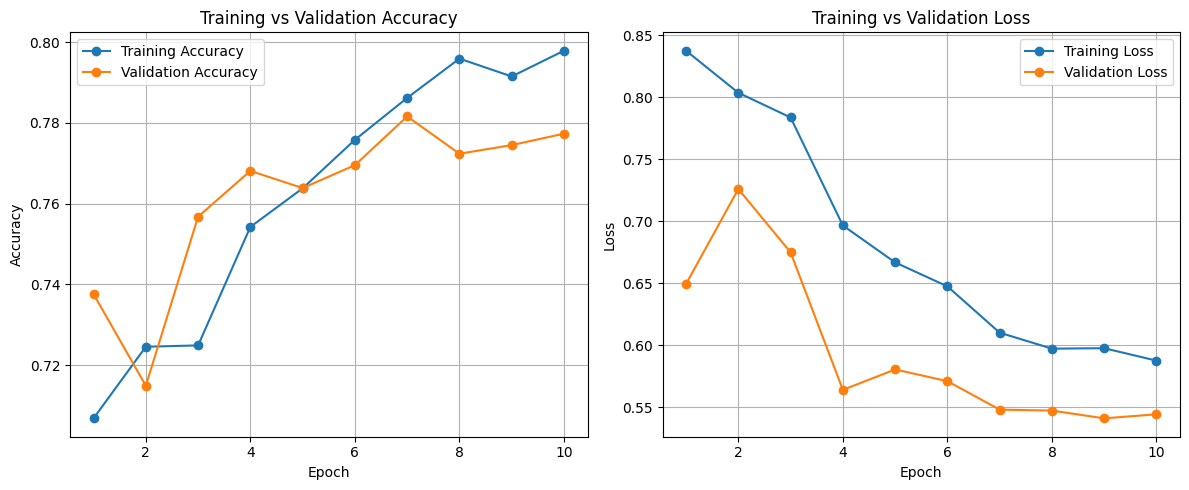

In [92]:
import matplotlib.pyplot as plt

history = history_balanced.history

epochs = range(1, len(history["accuracy"]) + 1)

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history["loss"], marker="o", label="Training Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

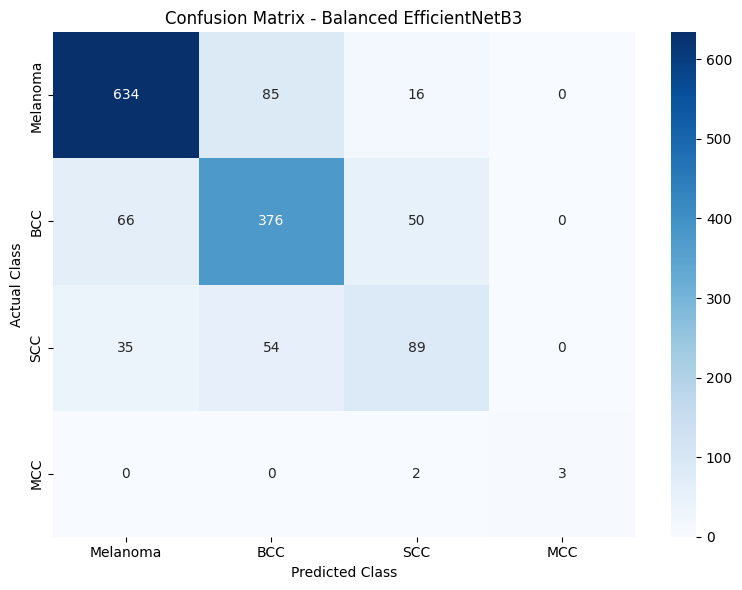

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([
    [634, 85, 16, 0],
    [66, 376, 50, 0],
    [35, 54, 89, 0],
    [0, 0, 2, 3]
])

class_names = [
    "Melanoma",
    "BCC",
    "SCC",
    "MCC"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Balanced EfficientNetB3")

plt.tight_layout()
plt.show()

In [95]:
import shutil

shutil.make_archive(
    "/kaggle/working/final_project_files",
    "zip",
    "/kaggle/working"
)

print("ZIP created successfully!")

ZIP created successfully!


In [96]:
import os
import shutil

files_to_save = [
    "/kaggle/working/models/FINAL_CANDIDATE_78_16.keras",
    "/kaggle/working/models/efficientnetb3_balanced_best.keras",
    "/kaggle/working/scc_finetuning_history.csv",
]

os.makedirs("/kaggle/working/final_project_files", exist_ok=True)

for file in files_to_save:
    if os.path.exists(file):
        shutil.copy2(
            file,
            "/kaggle/working/final_project_files/"
        )
        print("Copied:", file)
    else:
        print("NOT FOUND:", file)

shutil.make_archive(
    "/kaggle/working/final_project_files",
    "zip",
    "/kaggle/working/final_project_files"
)

print("\nZIP READY:")
print("/kaggle/working/final_project_files.zip")

Copied: /kaggle/working/models/FINAL_CANDIDATE_78_16.keras
Copied: /kaggle/working/models/efficientnetb3_balanced_best.keras
Copied: /kaggle/working/scc_finetuning_history.csv

ZIP READY:
/kaggle/working/final_project_files.zip


In [97]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/working/scc_finetuning_history.csv
/kaggle/working/final_project_files.zip
/kaggle/working/final_confusion_matrix.png
/kaggle/working/models/efficientnetb3_scc_finetuned_best.keras
/kaggle/working/models/efficientnetb3_balanced_best.keras
/kaggle/working/models/efficientnetb3_best.keras
/kaggle/working/models/FINAL_CANDIDATE_78_16.keras
/kaggle/working/.virtual_documents/__notebook_source__.ipynb
/kaggle/working/final_project_files/scc_finetuning_history.csv
/kaggle/working/final_project_files/efficientnetb3_balanced_best.keras
/kaggle/working/final_project_files/FINAL_CANDIDATE_78_16.keras
